# AIC Driver Detection -  Training

Notebook ini digunakan untuk training dan evaluasi model klasifikasi aktivitas pengemudi.

Model yang digunakan:
1. EfficientNet-B0 sebagai baseline
2. Improved ResNet50 sebagai model final

Dataset terdiri dari 9 kelas:
c0, c1, c2, c3, c4, c5, c6, c7, c9

Split dataset dilakukan berdasarkan driver/subject ID untuk menghindari
data leakage antar train, validation, dan test.

In [ ]:
import os
import random
import zipfile
from io import BytesIO

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score
)

print("Library berhasil di-load.")

Library berhasil di-load.


In [ ]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

print("Random seed:", SEED)

Random seed: 42


In [ ]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Device: cuda
GPU: Tesla T4


In [ ]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
dataset_folder = "/content/drive/MyDrive/dataset_AIC"

zip_path = os.path.join(
    dataset_folder,
    "state-farm-distracted-driver-detection.zip"
)

print("Dataset folder :", dataset_folder)
print("ZIP path       :", zip_path)

print("\nFolder exists :", os.path.exists(dataset_folder))
print("ZIP exists    :", os.path.exists(zip_path))

Dataset folder : /content/drive/MyDrive/dataset_AIC
ZIP path       : /content/drive/MyDrive/dataset_AIC/state-farm-distracted-driver-detection.zip

Folder exists : True
ZIP exists    : True


In [ ]:
with zipfile.ZipFile(zip_path, 'r') as z:
    zip_files = z.namelist()

print("Jumlah file di ZIP:", len(zip_files))

print("\n20 file pertama:")
for file in zip_files[:20]:
    print(file)

Jumlah file di ZIP: 102152

20 file pertama:
driver_imgs_list.csv
imgs/test/img_1.jpg
imgs/test/img_10.jpg
imgs/test/img_100.jpg
imgs/test/img_1000.jpg
imgs/test/img_100000.jpg
imgs/test/img_100001.jpg
imgs/test/img_100002.jpg
imgs/test/img_100003.jpg
imgs/test/img_100004.jpg
imgs/test/img_100005.jpg
imgs/test/img_100007.jpg
imgs/test/img_100008.jpg
imgs/test/img_100009.jpg
imgs/test/img_10001.jpg
imgs/test/img_100010.jpg
imgs/test/img_100011.jpg
imgs/test/img_100012.jpg
imgs/test/img_100013.jpg
imgs/test/img_100014.jpg


In [ ]:
csv_files = [
    f for f in zip_files
    if f.lower().endswith(".csv")
]

print("CSV yang ditemukan:")

for f in csv_files:
    print(f)

CSV yang ditemukan:
driver_imgs_list.csv
sample_submission.csv


In [ ]:
csv_name = csv_files[0]

with zipfile.ZipFile(zip_path, 'r') as z:
    with z.open(csv_name) as f:
        df = pd.read_csv(f)

print("Jumlah data:", len(df))
print("Kolom:", df.columns.tolist())

display(df.head())

Jumlah data: 22424
Kolom: ['subject', 'classname', 'img']


,subject,classname,img
0,p002,c0,img_44733.jpg
1,p002,c0,img_72999.jpg
2,p002,c0,img_25094.jpg
3,p002,c0,img_69092.jpg
4,p002,c0,img_92629.jpg


In [ ]:
# Kelas yang digunakan dalam eksperimen
selected_classes = [
    'c0', 'c1', 'c2', 'c3',
    'c4', 'c5', 'c6', 'c7', 'c9'
]

# Buang kelas c8
df = df[
    df["classname"].isin(selected_classes)
].reset_index(drop=True)

print("Jumlah gambar setelah membuang c8 :", len(df))
print("Jumlah driver :", df["subject"].nunique())
print("Jumlah kelas  :", df["classname"].nunique())

print("\nKelas yang digunakan:")
print(sorted(df["classname"].unique()))

Jumlah gambar setelah membuang c8 : 20513
Jumlah driver : 26
Jumlah kelas  : 9

Kelas yang digunakan:
['c0', 'c1', 'c2', 'c3', 'c4', 'c5', 'c6', 'c7', 'c9']


In [ ]:
class_distribution = (
    df["classname"]
    .value_counts()
    .sort_index()
)

print("=== DISTRIBUSI SELURUH DATA ===")
display(class_distribution.to_frame("jumlah"))

=== DISTRIBUSI SELURUH DATA ===


,jumlah
classname,
c0,2489
c1,2267
c2,2317
c3,2346
c4,2326
c5,2312
c6,2325
c7,2002
c9,2129


In [ ]:
train_drivers = [
    'p015', 'p016', 'p021', 'p022',
    'p024', 'p035', 'p041', 'p042',
    'p045', 'p047', 'p051', 'p052',
    'p056', 'p061', 'p064', 'p066',
    'p072', 'p081'
]

val_drivers = [
    'p012', 'p014', 'p039', 'p049'
]

test_drivers = [
    'p002', 'p026', 'p050', 'p075'
]

print("Train drivers:", len(train_drivers))
print("Validation drivers:", len(val_drivers))
print("Test drivers:", len(test_drivers))

Train drivers: 18
Validation drivers: 4
Test drivers: 4


In [ ]:
df_train = df[
    df["subject"].isin(train_drivers)
].reset_index(drop=True)

df_val = df[
    df["subject"].isin(val_drivers)
].reset_index(drop=True)

df_test = df[
    df["subject"].isin(test_drivers)
].reset_index(drop=True)

print("Jumlah gambar:")
print("Train      :", len(df_train))
print("Validation :", len(df_val))
print("Test       :", len(df_test))

print("\nJumlah driver:")
print("Train      :", df_train["subject"].nunique())
print("Validation :", df_val["subject"].nunique())
print("Test       :", df_test["subject"].nunique())

Jumlah gambar:
Train      : 14161
Validation : 3112
Test       : 3240

Jumlah driver:
Train      : 18
Validation : 4
Test       : 4


In [ ]:
print("========== TRAIN ==========")
display(
    df_train["classname"]
    .value_counts()
    .sort_index()
    .to_frame("jumlah")
)

print("========== VALIDATION ==========")
display(
    df_val["classname"]
    .value_counts()
    .sort_index()
    .to_frame("jumlah")
)

print("========== TEST ==========")
display(
    df_test["classname"]
    .value_counts()
    .sort_index()
    .to_frame("jumlah")
)

========== TRAIN ==========


,jumlah
classname,
c0,1746
c1,1592
c2,1584
c3,1595
c4,1573
c5,1558
c6,1592
c7,1383
c9,1538


========== VALIDATION ==========


,jumlah
classname,
c0,333
c1,346
c2,380
c3,364
c4,371
c5,378
c6,358
c7,287
c9,295


========== TEST ==========


,jumlah
classname,
c0,410
c1,329
c2,353
c3,387
c4,382
c5,376
c6,375
c7,332
c9,296


In [ ]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),

    transforms.RandomHorizontalFlip(),

    transforms.RandomRotation(10),

    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [ ]:
val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [ ]:
class ZipImageDataset(Dataset):

    def __init__(self, dataframe, zip_path, transform=None):

        self.df = dataframe.reset_index(drop=True)
        self.zip_path = zip_path
        self.transform = transform

        self.class_to_idx = {
            'c0': 0,
            'c1': 1,
            'c2': 2,
            'c3': 3,
            'c4': 4,
            'c5': 5,
            'c6': 6,
            'c7': 7,
            'c9': 8
        }

        self.zip_file = zipfile.ZipFile(
            self.zip_path,
            'r'
        )

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):

        row = self.df.iloc[idx]

        classname = row["classname"]
        img_name = row["img"]

        zip_img_path = (
            f"imgs/train/{classname}/{img_name}"
        )

        image_bytes = self.zip_file.read(
            zip_img_path
        )

        image = Image.open(
            BytesIO(image_bytes)
        ).convert("RGB")

        if self.transform:
            image = self.transform(image)

        label = self.class_to_idx[classname]

        return image, label

In [ ]:
train_dataset = ZipImageDataset(
    df_train,
    zip_path,
    transform=train_transform
)

val_dataset = ZipImageDataset(
    df_val,
    zip_path,
    transform=val_test_transform
)

test_dataset = ZipImageDataset(
    df_test,
    zip_path,
    transform=val_test_transform
)

print("Train      :", len(train_dataset))
print("Validation :", len(val_dataset))
print("Test       :", len(test_dataset))

Train      : 14161
Validation : 3112
Test       : 3240


In [ ]:
BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

print("DataLoader berhasil dibuat.")

DataLoader berhasil dibuat.


In [ ]:
images, labels = next(iter(train_loader))

print("Input :", images.shape)
print("Labels:", labels.shape)

Input : torch.Size([32, 3, 224, 224])
Labels: torch.Size([32])


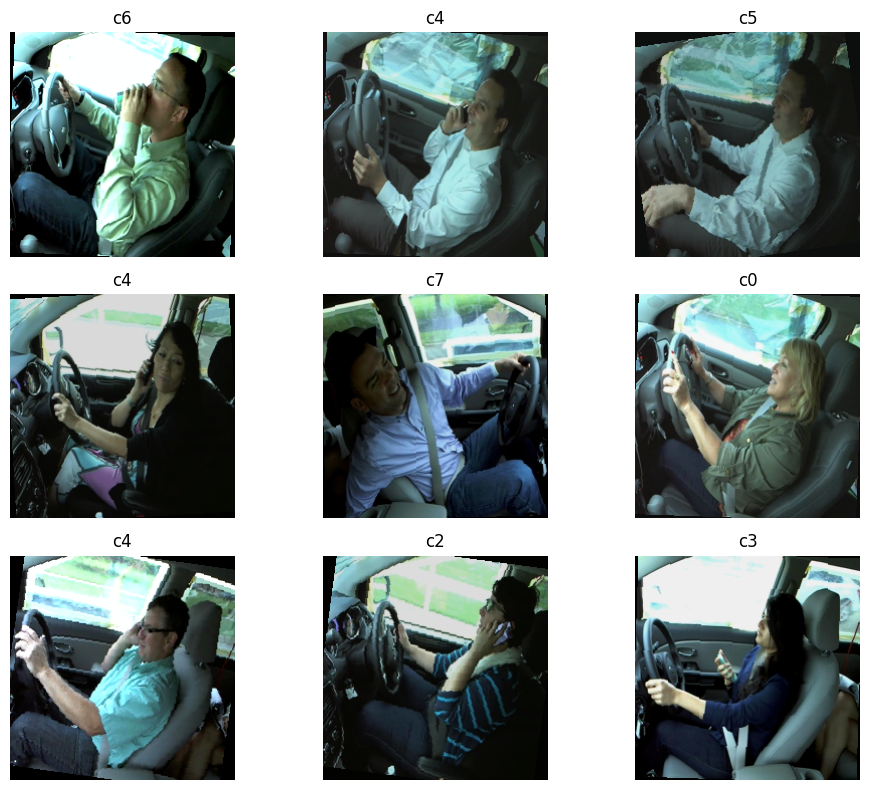

In [ ]:
class_names = [
    'c0', 'c1', 'c2', 'c3',
    'c4', 'c5', 'c6', 'c7', 'c9'
]

plt.figure(figsize=(10, 8))

for i in range(9):

    plt.subplot(3, 3, i + 1)

    image = images[i].permute(1, 2, 0).numpy()

    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])

    image = image * std + mean
    image = np.clip(image, 0, 1)

    plt.imshow(image)

    plt.title(
        class_names[labels[i].item()]
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
num_classes = 9

model_b0 = models.efficientnet_b0(
    weights=models.EfficientNet_B0_Weights.DEFAULT
)

# Ganti classifier bawaan menjadi 9 kelas
in_features = model_b0.classifier[1].in_features

model_b0.classifier[1] = nn.Linear(
    in_features,
    num_classes
)

model_b0 = model_b0.to(device)

print(model_b0.classifier)

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 110MB/s] 


Sequential(
  (0): Dropout(p=0.2, inplace=True)
  (1): Linear(in_features=1280, out_features=9, bias=True)
)


In [ ]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model_b0.parameters(),
    lr=0.0001
)

print("Loss function :", criterion)
print("Optimizer     :", optimizer)

Loss function : CrossEntropyLoss()
Optimizer     : Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.0001
    maximize: False
    weight_decay: 0
)


In [ ]:
model_b0.eval()

with torch.no_grad():

    sample_images, sample_labels = next(
        iter(train_loader)
    )

    sample_images = sample_images.to(device)

    outputs = model_b0(sample_images)

print("Input  :", sample_images.shape)
print("Output :", outputs.shape)
print("Label  :", sample_labels.shape)

Input  : torch.Size([32, 3, 224, 224])
Output : torch.Size([32, 9])
Label  : torch.Size([32])


In [ ]:
def train_one_epoch(
    model,
    loader,
    criterion,
    optimizer,
    device
):

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(
            outputs,
            labels
        )

        loss.backward()
        optimizer.step()

        running_loss += (
            loss.item() * images.size(0)
        )

        _, predicted = torch.max(
            outputs,
            1
        )

        total += labels.size(0)

        correct += (
            predicted == labels
        ).sum().item()

    epoch_loss = running_loss / total
    epoch_acc = correct / total

    return epoch_loss, epoch_acc

In [ ]:
def validate(
    model,
    loader,
    criterion,
    device
):

    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(
                outputs,
                labels
            )

            running_loss += (
                loss.item() * images.size(0)
            )

            _, predicted = torch.max(
                outputs,
                1
            )

            total += labels.size(0)

            correct += (
                predicted == labels
            ).sum().item()

    epoch_loss = running_loss / total
    epoch_acc = correct / total

    return epoch_loss, epoch_acc

In [ ]:
EPOCHS = 10

best_val_acc = 0.0

history_b0 = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": []
}

best_model_path = (
    "/content/drive/MyDrive/dataset_AIC/"
    "best_efficientnet_b0.pth"
)

for epoch in range(EPOCHS):

    print(
        f"\nEpoch {epoch + 1}/{EPOCHS}"
    )
    print("-" * 40)

    train_loss, train_acc = train_one_epoch(
        model_b0,
        train_loader,
        criterion,
        optimizer,
        device
    )

    val_loss, val_acc = validate(
        model_b0,
        val_loader,
        criterion,
        device
    )

    history_b0["train_loss"].append(
        train_loss
    )

    history_b0["train_acc"].append(
        train_acc
    )

    history_b0["val_loss"].append(
        val_loss
    )

    history_b0["val_acc"].append(
        val_acc
    )

    print(
        f"Train Loss : {train_loss:.4f}"
    )

    print(
        f"Train Acc  : {train_acc:.4f}"
    )

    print(
        f"Val Loss   : {val_loss:.4f}"
    )

    print(
        f"Val Acc    : {val_acc:.4f}"
    )

    # Simpan model terbaik berdasarkan validation accuracy
    if val_acc > best_val_acc:

        best_val_acc = val_acc

        torch.save(
            model_b0.state_dict(),
            best_model_path
        )

        print("✓ Best model saved!")

print("\nTraining EfficientNet-B0 selesai.")

print(
    f"Best validation accuracy: "
    f"{best_val_acc:.4f}"
)

print(
    "Model tersimpan di:",
    best_model_path
)


Epoch 1/10
----------------------------------------
Train Loss : 0.5102
Train Acc  : 0.8698
Val Loss   : 0.2789
Val Acc    : 0.9181
✓ Best model saved!

Epoch 2/10
----------------------------------------
Train Loss : 0.0431
Train Acc  : 0.9895
Val Loss   : 0.2561
Val Acc    : 0.9242
✓ Best model saved!

Epoch 3/10
----------------------------------------
Train Loss : 0.0206
Train Acc  : 0.9949
Val Loss   : 0.3928
Val Acc    : 0.8891

Epoch 4/10
----------------------------------------
Train Loss : 0.0184
Train Acc  : 0.9951
Val Loss   : 0.2726
Val Acc    : 0.9219

Epoch 5/10
----------------------------------------
Train Loss : 0.0106
Train Acc  : 0.9969
Val Loss   : 0.3242
Val Acc    : 0.9026

Epoch 6/10
----------------------------------------
Train Loss : 0.0127
Train Acc  : 0.9963
Val Loss   : 0.4123
Val Acc    : 0.8885

Epoch 7/10
----------------------------------------
Train Loss : 0.0091
Train Acc  : 0.9972
Val Loss   : 0.2743
Val Acc    : 0.9193

Epoch 8/10
-----------------

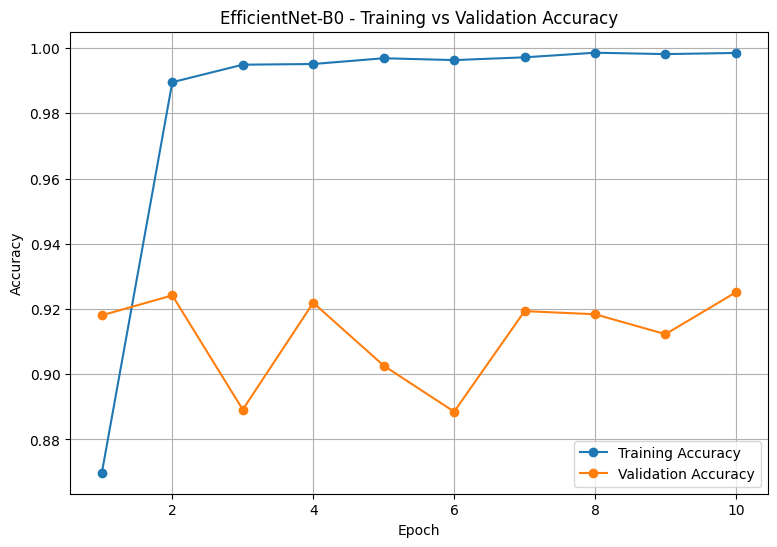

In [41]:
epochs_range = range(
    1,
    EPOCHS + 1
)

plt.figure(figsize=(9, 6))

plt.plot(
    epochs_range,
    history_b0["train_acc"],
    marker="o",
    label="Training Accuracy"
)

plt.plot(
    epochs_range,
    history_b0["val_acc"],
    marker="o",
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.title(
    "EfficientNet-B0 - Training vs Validation Accuracy"
)

plt.legend()
plt.grid(True)

plt.show()

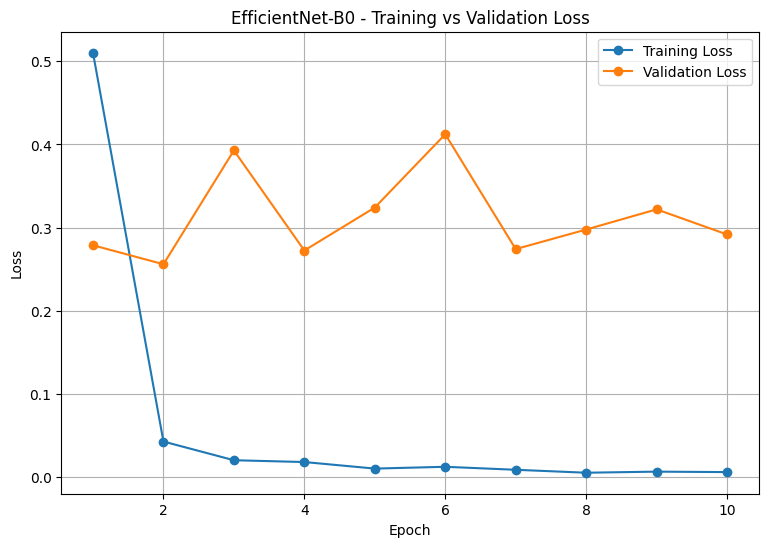

In [42]:
plt.figure(figsize=(9, 6))

plt.plot(
    epochs_range,
    history_b0["train_loss"],
    marker="o",
    label="Training Loss"
)

plt.plot(
    epochs_range,
    history_b0["val_loss"],
    marker="o",
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title(
    "EfficientNet-B0 - Training vs Validation Loss"
)

plt.legend()
plt.grid(True)

plt.show()

In [43]:
model_b0.load_state_dict(
    torch.load(
        best_model_path,
        map_location=device
    )
)

model_b0 = model_b0.to(device)

model_b0.eval()

print("Best EfficientNet-B0 berhasil dimuat.")

Best EfficientNet-B0 berhasil dimuat.


In [44]:
test_loss, test_acc = validate(
    model_b0,
    test_loader,
    criterion,
    device
)

print(
    f"Test Loss     : {test_loss:.4f}"
)

print(
    f"Test Accuracy : {test_acc:.4f}"
)

Test Loss     : 0.4897
Test Accuracy : 0.8698


In [45]:
model_b0.eval()

all_labels = []
all_predictions = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        outputs = model_b0(images)

        _, predictions = torch.max(
            outputs,
            1
        )

        all_labels.extend(
            labels.numpy()
        )

        all_predictions.extend(
            predictions.cpu().numpy()
        )

print(
    classification_report(
        all_labels,
        all_predictions,
        target_names=class_names,
        digits=4
    )
)

              precision    recall  f1-score   support

          c0     0.6341    0.7902    0.7036       410
          c1     0.9873    0.9483    0.9674       329
          c2     0.9539    0.9972    0.9751       353
          c3     0.8217    0.9767    0.8926       387
          c4     1.0000    0.8874    0.9404       382
          c5     0.9439    0.9840    0.9635       376
          c6     0.9873    0.8267    0.8999       375
          c7     0.9736    0.8886    0.9291       332
          c9     0.5847    0.4662    0.5188       296

    accuracy                         0.8698      3240
   macro avg     0.8763    0.8628    0.8656      3240
weighted avg     0.8775    0.8698    0.8696      3240



In [46]:
cm = confusion_matrix(
    all_labels,
    all_predictions
)

print(cm)

[[324   2   0   0   0   0   1   0  83]
 [  1 312   0   9   0   0   2   5   0]
 [  0   0 352   0   0   0   1   0   0]
 [  4   2   0 378   0   2   0   0   1]
 [ 31   0   2   7 339   1   0   0   2]
 [  5   0   0   0   0 370   0   0   1]
 [  0   0   0  64   0   0 310   1   0]
 [  0   0  15   0   0  11   0 295  11]
 [146   0   0   2   0   8   0   2 138]]


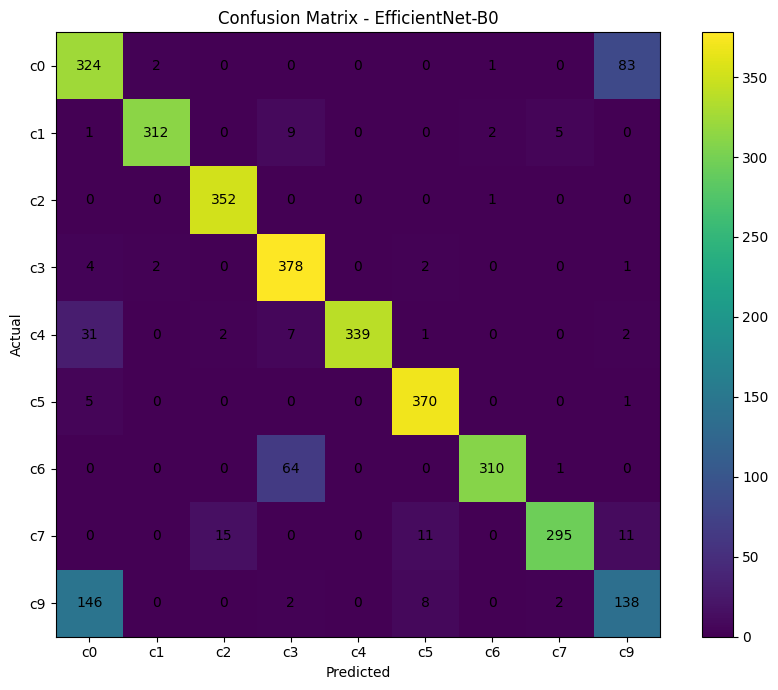

In [47]:
plt.figure(figsize=(9, 7))

plt.imshow(cm)

plt.xticks(
    range(len(class_names)),
    class_names
)

plt.yticks(
    range(len(class_names)),
    class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title(
    "Confusion Matrix - EfficientNet-B0"
)

plt.colorbar()

for i in range(len(class_names)):
    for j in range(len(class_names)):

        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.tight_layout()
plt.show()

In [48]:
from sklearn.metrics import f1_score

macro_f1_b0 = f1_score(
    all_labels,
    all_predictions,
    average="macro"
)

weighted_f1_b0 = f1_score(
    all_labels,
    all_predictions,
    average="weighted"
)

print("=== EFFICIENTNET-B0 BASELINE ===")

print(
    f"Best Validation Accuracy : "
    f"{best_val_acc * 100:.2f}%"
)

print(
    f"Test Accuracy            : "
    f"{test_acc * 100:.2f}%"
)

print(
    f"Macro F1                 : "
    f"{macro_f1_b0 * 100:.2f}%"
)

print(
    f"Weighted F1              : "
    f"{weighted_f1_b0 * 100:.2f}%"
)

=== EFFICIENTNET-B0 BASELINE ===
Best Validation Accuracy : 92.51%
Test Accuracy            : 86.98%
Macro F1                 : 86.56%
Weighted F1              : 86.96%


In [49]:
import os

b0_path = "/content/drive/MyDrive/dataset_AIC/best_efficientnet_b0.pth"

print("File exists:", os.path.exists(b0_path))

if os.path.exists(b0_path):
    print("Ukuran file:", os.path.getsize(b0_path) / (1024**2), "MB")
    print("Lokasi:", b0_path)

File exists: True
Ukuran file: 15.620671272277832 MB
Lokasi: /content/drive/MyDrive/dataset_AIC/best_efficientnet_b0.pth


In [50]:
results_dir = "/content/drive/MyDrive/dataset_AIC/results"

os.makedirs(results_dir, exist_ok=True)

print("Folder results:", results_dir)
print("Exists:", os.path.exists(results_dir))

Folder results: /content/drive/MyDrive/dataset_AIC/results
Exists: True


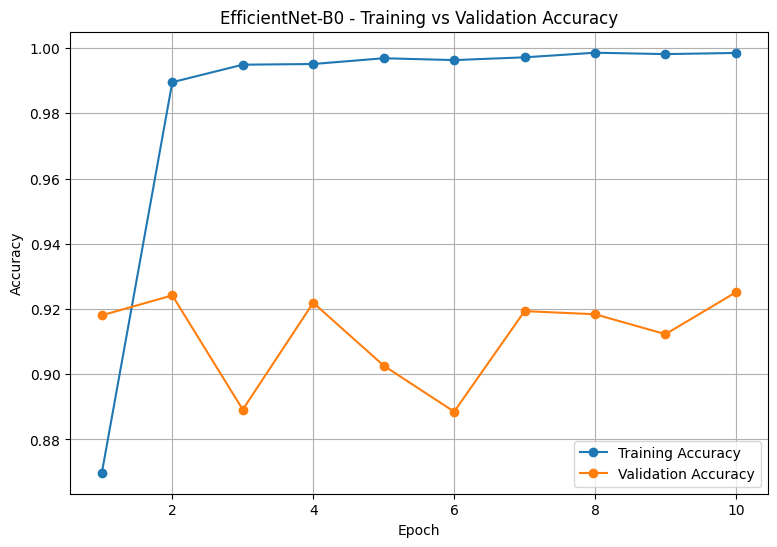

In [51]:
plt.figure(figsize=(9, 6))

plt.plot(
    epochs_range,
    history_b0["train_acc"],
    marker="o",
    label="Training Accuracy"
)

plt.plot(
    epochs_range,
    history_b0["val_acc"],
    marker="o",
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("EfficientNet-B0 - Training vs Validation Accuracy")
plt.legend()
plt.grid(True)

plt.savefig(
    os.path.join(
        results_dir,
        "efficientnet_b0_accuracy.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

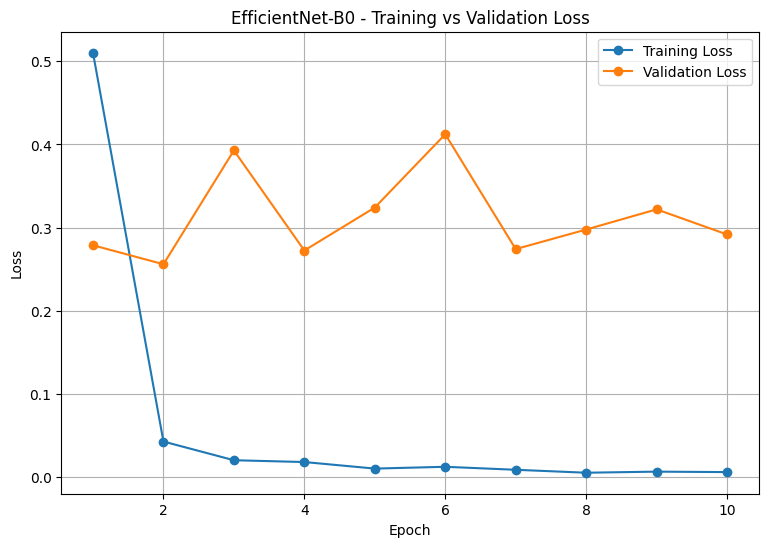

In [52]:
plt.figure(figsize=(9, 6))

plt.plot(
    epochs_range,
    history_b0["train_loss"],
    marker="o",
    label="Training Loss"
)

plt.plot(
    epochs_range,
    history_b0["val_loss"],
    marker="o",
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("EfficientNet-B0 - Training vs Validation Loss")
plt.legend()
plt.grid(True)

plt.savefig(
    os.path.join(
        results_dir,
        "efficientnet_b0_loss.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# MODEL 2 — Improved ResNet50

ResNet50 digunakan sebagai model pembanding terhadap EfficientNet-B0.

Improvement:
- Dropout
- Weight decay
- Learning rate scheduler
- Early stopping

In [53]:
num_classes = 9

model_resnet = models.resnet50(
    weights=models.ResNet50_Weights.DEFAULT
)

# Ganti fully-connected layer
in_features = model_resnet.fc.in_features

model_resnet.fc = nn.Sequential(
    nn.Dropout(p=0.5),
    nn.Linear(
        in_features,
        num_classes
    )
)

model_resnet = model_resnet.to(device)

print(model_resnet.fc)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 194MB/s]


Sequential(
  (0): Dropout(p=0.5, inplace=False)
  (1): Linear(in_features=2048, out_features=9, bias=True)
)


In [54]:
criterion_resnet = nn.CrossEntropyLoss()

optimizer_resnet = optim.Adam(
    model_resnet.parameters(),
    lr=0.0001,
    weight_decay=1e-4
)

print(optimizer_resnet)

Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.0001
    maximize: False
    weight_decay: 0.0001
)


In [55]:
scheduler_resnet = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_resnet,
    mode="min",
    factor=0.5,
    patience=1
)

print("Scheduler berhasil dibuat.")

Scheduler berhasil dibuat.


In [56]:
model_resnet.eval()

with torch.no_grad():

    sample_images, sample_labels = next(
        iter(train_loader)
    )

    sample_images = sample_images.to(device)

    outputs = model_resnet(
        sample_images
    )

print("Input :", sample_images.shape)
print("Output:", outputs.shape)
print("Labels:", sample_labels.shape)

Input : torch.Size([32, 3, 224, 224])
Output: torch.Size([32, 9])
Labels: torch.Size([32])


In [57]:
EPOCHS_RESNET = 15

best_val_acc_resnet = 0.0

patience = 3
patience_counter = 0

history_resnet = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": []
}

resnet_path = (
    "/content/drive/MyDrive/dataset_AIC/"
    "best_resnet50_improved.pth"
)

for epoch in range(EPOCHS_RESNET):

    print(
        f"\nEpoch {epoch + 1}/{EPOCHS_RESNET}"
    )

    print("-" * 40)

    # TRAIN
    train_loss, train_acc = train_one_epoch(
        model_resnet,
        train_loader,
        criterion_resnet,
        optimizer_resnet,
        device
    )

    # VALIDATION
    val_loss, val_acc = validate(
        model_resnet,
        val_loader,
        criterion_resnet,
        device
    )

    # Simpan history
    history_resnet["train_loss"].append(
        train_loss
    )

    history_resnet["train_acc"].append(
        train_acc
    )

    history_resnet["val_loss"].append(
        val_loss
    )

    history_resnet["val_acc"].append(
        val_acc
    )

    print(
        f"Train Loss : {train_loss:.4f}"
    )

    print(
        f"Train Acc  : {train_acc:.4f}"
    )

    print(
        f"Val Loss   : {val_loss:.4f}"
    )

    print(
        f"Val Acc    : {val_acc:.4f}"
    )

    # Scheduler
    scheduler_resnet.step(val_loss)

    # Best model
    if val_acc > best_val_acc_resnet:

        best_val_acc_resnet = val_acc

        patience_counter = 0

        torch.save(
            model_resnet.state_dict(),
            resnet_path
        )

        print("✓ Best ResNet50 saved!")

    else:

        patience_counter += 1

        print(
            f"No improvement "
            f"({patience_counter}/{patience})"
        )

    # Early stopping
    if patience_counter >= patience:

        print("\nEarly stopping!")

        break

print("\nTraining ResNet50 selesai.")

print(
    f"Best validation accuracy: "
    f"{best_val_acc_resnet:.4f}"
)

print(
    "Model tersimpan di:",
    resnet_path
)


Epoch 1/15
----------------------------------------
Train Loss : 0.3922
Train Acc  : 0.8868
Val Loss   : 0.3348
Val Acc    : 0.9030
✓ Best ResNet50 saved!

Epoch 2/15
----------------------------------------
Train Loss : 0.0342
Train Acc  : 0.9912
Val Loss   : 0.3460
Val Acc    : 0.8956
No improvement (1/3)

Epoch 3/15
----------------------------------------
Train Loss : 0.0231
Train Acc  : 0.9938
Val Loss   : 0.2656
Val Acc    : 0.9206
✓ Best ResNet50 saved!

Epoch 4/15
----------------------------------------
Train Loss : 0.0102
Train Acc  : 0.9976
Val Loss   : 0.5374
Val Acc    : 0.8985
No improvement (1/3)

Epoch 5/15
----------------------------------------
Train Loss : 0.0173
Train Acc  : 0.9953
Val Loss   : 0.3258
Val Acc    : 0.8991
No improvement (2/3)

Epoch 6/15
----------------------------------------
Train Loss : 0.0066
Train Acc  : 0.9984
Val Loss   : 0.3548
Val Acc    : 0.9071
No improvement (3/3)

Early stopping!

Training ResNet50 selesai.
Best validation accuracy: 0

In [58]:
print(
    "File exists:",
    os.path.exists(resnet_path)
)

if os.path.exists(resnet_path):

    print(
        "Ukuran:",
        os.path.getsize(resnet_path) / (1024**2),
        "MB"
    )

    print(
        "Lokasi:",
        resnet_path
    )

File exists: True
Ukuran: 90.05440616607666 MB
Lokasi: /content/drive/MyDrive/dataset_AIC/best_resnet50_improved.pth


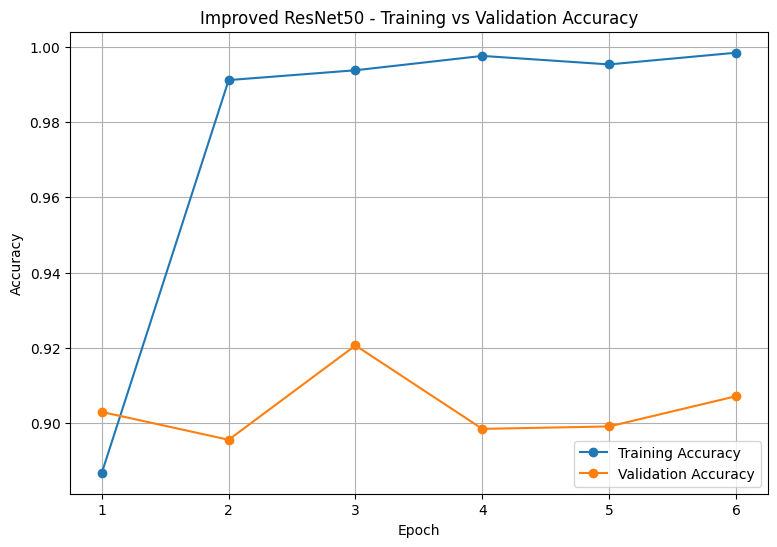

In [59]:
epochs_resnet = range(
    1,
    len(history_resnet["train_acc"]) + 1
)

plt.figure(figsize=(9, 6))

plt.plot(
    epochs_resnet,
    history_resnet["train_acc"],
    marker="o",
    label="Training Accuracy"
)

plt.plot(
    epochs_resnet,
    history_resnet["val_acc"],
    marker="o",
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.title(
    "Improved ResNet50 - Training vs Validation Accuracy"
)

plt.legend()
plt.grid(True)

plt.savefig(
    os.path.join(
        results_dir,
        "resnet50_improved_accuracy.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

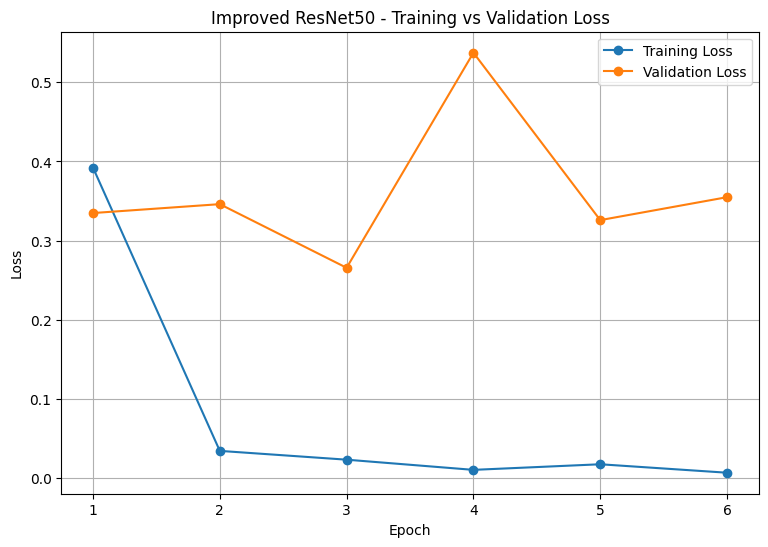

In [60]:
plt.figure(figsize=(9, 6))

plt.plot(
    epochs_resnet,
    history_resnet["train_loss"],
    marker="o",
    label="Training Loss"
)

plt.plot(
    epochs_resnet,
    history_resnet["val_loss"],
    marker="o",
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title(
    "Improved ResNet50 - Training vs Validation Loss"
)

plt.legend()
plt.grid(True)

plt.savefig(
    os.path.join(
        results_dir,
        "resnet50_improved_loss.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [61]:
model_resnet.load_state_dict(
    torch.load(
        resnet_path,
        map_location=device
    )
)

model_resnet = model_resnet.to(device)

model_resnet.eval()

print(
    "Best ResNet50 berhasil dimuat."
)

Best ResNet50 berhasil dimuat.


In [62]:
test_loss_resnet, test_acc_resnet = validate(
    model_resnet,
    test_loader,
    criterion_resnet,
    device
)

print(
    f"Test Loss     : "
    f"{test_loss_resnet:.4f}"
)

print(
    f"Test Accuracy : "
    f"{test_acc_resnet:.4f}"
)

Test Loss     : 0.2401
Test Accuracy : 0.9207


In [63]:
model_resnet.eval()

all_labels_resnet = []
all_predictions_resnet = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        outputs = model_resnet(
            images
        )

        _, predictions = torch.max(
            outputs,
            1
        )

        all_labels_resnet.extend(
            labels.numpy()
        )

        all_predictions_resnet.extend(
            predictions.cpu().numpy()
        )

print(
    classification_report(
        all_labels_resnet,
        all_predictions_resnet,
        target_names=class_names,
        digits=4
    )
)

              precision    recall  f1-score   support

          c0     0.7716    0.7415    0.7562       410
          c1     0.9909    0.9970    0.9939       329
          c2     0.9605    0.9632    0.9618       353
          c3     0.9742    0.9742    0.9742       387
          c4     0.9658    0.9607    0.9633       382
          c5     0.8200    0.9814    0.8935       376
          c6     0.9839    0.9787    0.9813       375
          c7     0.9587    0.9789    0.9687       332
          c9     0.8879    0.6959    0.7803       296

    accuracy                         0.9207      3240
   macro avg     0.9237    0.9190    0.9192      3240
weighted avg     0.9215    0.9207    0.9191      3240



In [64]:
cm_resnet = confusion_matrix(
    all_labels_resnet,
    all_predictions_resnet
)

print(cm_resnet)

[[304   2   8   0   9  63   0   0  24]
 [  1 328   0   0   0   0   0   0   0]
 [  0   0 340   0   0   0   6   7   0]
 [  4   1   2 377   2   0   0   1   0]
 [  1   0   4   7 367   0   0   3   0]
 [  5   0   0   0   0 369   0   0   2]
 [  6   0   0   1   0   1 367   0   0]
 [  0   0   0   0   0   7   0 325   0]
 [ 73   0   0   2   2  10   0   3 206]]


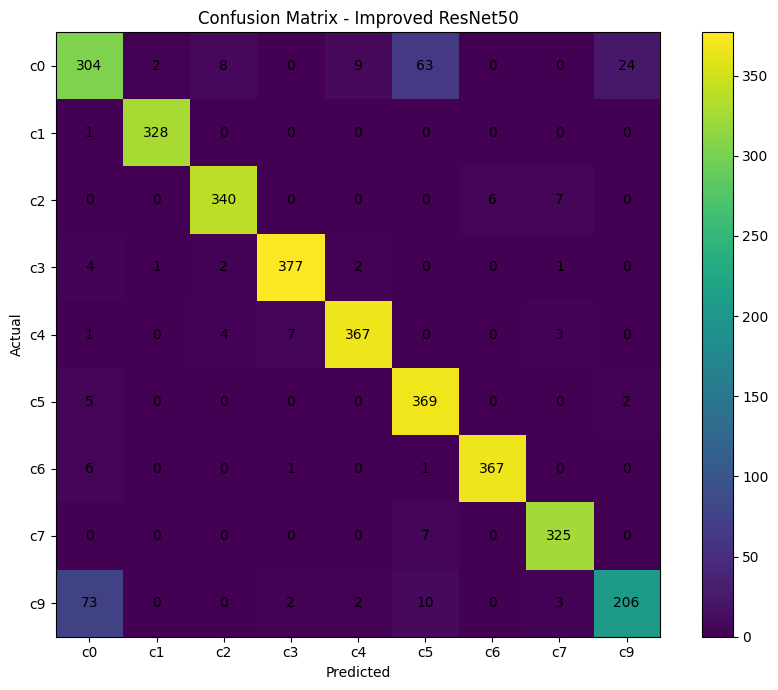

In [65]:
plt.figure(figsize=(9, 7))

plt.imshow(cm_resnet)

plt.xticks(
    range(len(class_names)),
    class_names
)

plt.yticks(
    range(len(class_names)),
    class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title(
    "Confusion Matrix - Improved ResNet50"
)

plt.colorbar()

for i in range(len(class_names)):

    for j in range(len(class_names)):

        plt.text(
            j,
            i,
            cm_resnet[i, j],
            ha="center",
            va="center"
        )

plt.tight_layout()

plt.savefig(
    os.path.join(
        results_dir,
        "resnet50_improved_confusion_matrix.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [66]:
macro_f1_resnet = f1_score(
    all_labels_resnet,
    all_predictions_resnet,
    average="macro"
)

weighted_f1_resnet = f1_score(
    all_labels_resnet,
    all_predictions_resnet,
    average="weighted"
)

print("=== IMPROVED RESNET50 ===")

print(
    f"Best Validation Accuracy : "
    f"{best_val_acc_resnet * 100:.2f}%"
)

print(
    f"Test Accuracy            : "
    f"{test_acc_resnet * 100:.2f}%"
)

print(
    f"Macro F1                 : "
    f"{macro_f1_resnet * 100:.2f}%"
)

print(
    f"Weighted F1              : "
    f"{weighted_f1_resnet * 100:.2f}%"
)

=== IMPROVED RESNET50 ===
Best Validation Accuracy : 92.06%
Test Accuracy            : 92.07%
Macro F1                 : 91.92%
Weighted F1              : 91.91%


In [67]:
macro_f1_resnet = f1_score(
    all_labels_resnet,
    all_predictions_resnet,
    average="macro"
)

weighted_f1_resnet = f1_score(
    all_labels_resnet,
    all_predictions_resnet,
    average="weighted"
)

print("=== IMPROVED RESNET50 ===")

print(
    f"Best Validation Accuracy : "
    f"{best_val_acc_resnet * 100:.2f}%"
)

print(
    f"Test Accuracy            : "
    f"{test_acc_resnet * 100:.2f}%"
)

print(
    f"Macro F1                 : "
    f"{macro_f1_resnet * 100:.2f}%"
)

print(
    f"Weighted F1              : "
    f"{weighted_f1_resnet * 100:.2f}%"
)

=== IMPROVED RESNET50 ===
Best Validation Accuracy : 92.06%
Test Accuracy            : 92.07%
Macro F1                 : 91.92%
Weighted F1              : 91.91%


In [68]:
import pandas as pd

comparison = pd.DataFrame({
    "Model": [
        "EfficientNet-B0",
        "ResNet50"
    ],
    "Best Validation Accuracy (%)": [
        92.51,
        92.06
    ],
    "Test Accuracy (%)": [
        86.98,
        92.07
    ],
    "Macro F1 (%)": [
        86.56,
        91.92
    ],
    "Weighted F1 (%)": [
        86.96,
        91.91
    ]
})

print("=== PERBANDINGAN MODEL ===")
display(comparison)

# Menentukan model terbaik berdasarkan Test Accuracy
best_test_model = comparison.loc[
    comparison["Test Accuracy (%)"].idxmax()
]

# Menentukan model terbaik berdasarkan Macro F1
best_f1_model = comparison.loc[
    comparison["Macro F1 (%)"].idxmax()
]

print("\n=== KESIMPULAN ===")
print(
    f"Model dengan Test Accuracy terbaik : "
    f"{best_test_model['Model']} ({best_test_model['Test Accuracy (%)']:.2f}%)"
)

print(
    f"Model dengan Macro F1 terbaik       : "
    f"{best_f1_model['Model']} ({best_f1_model['Macro F1 (%)']:.2f}%)"
)

=== PERBANDINGAN MODEL ===


,Model,Best Validation Accuracy (%),Test Accuracy (%),Macro F1 (%),Weighted F1 (%)
0,EfficientNet-B0,92.51,86.98,86.56,86.96
1,ResNet50,92.06,92.07,91.92,91.91



=== KESIMPULAN ===
Model dengan Test Accuracy terbaik : ResNet50 (92.07%)
Model dengan Macro F1 terbaik       : ResNet50 (91.92%)
